In [2]:
from google.colab import drive, files
drive.mount('/content/drive')
!pip install ultralytics opencv-python pandas
from ultralytics import YOLO
import shutil
import os
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import yaml
from IPython.display import Image, display

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="B6S1UWw3tkVY7061vg9U")
project = rf.workspace("footbaldetection-tiny4").project("finalv2")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...


In [4]:
# Load a model
model = YOLO("yolo26m.pt", )

In [7]:
DATA_YAML_PATH = "/content/drive/MyDrive/SoccerNet.yolo26/data.yaml"
# Train the model
train_results = model.train(
    data="/content/FinalV2-1/data.yaml",  # path to dataset YAML
    epochs=80,  # number of training epochs
    #imgsz=1024,
    hsv_s=0.5,
    hsv_v=0.5,
    translate=0.1,
    scale=0.6,
    perspective=0.0005,
    shear=40,
    fliplr=0.5,
    exist_ok=True)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FinalV2-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [8]:
MODEL_PATH = "/content/yolo26m.pt"
SOURCE = "/content/drive/MyDrive/SoccerNet.yolo26/test/images"

results = model.predict(
    source="/content/FinalV2-1/test/images",
    #imgsz=1024,
    conf=0.5,
    iou=0.5,
    save=True,
    project="/content",
    name="predicciones_test",
    exist_ok=True,
)



image 1/288 /content/FinalV2-1/test/images/100_PNG.rf.62515d18bcdd77f10fd85595b189d664.jpg: 640x640 1 ball, 1 goalkeeper, 7 players, 12.2ms
image 2/288 /content/FinalV2-1/test/images/10_PNG.rf.0d778e176cc02a67735398924e800e9c.jpg: 640x640 1 ball, 1 goalkeeper, 6 players, 1 referee, 15.4ms
image 3/288 /content/FinalV2-1/test/images/111_PNG.rf.2be3c370d8cafb2319c9f5c06d6cf4d7.jpg: 640x640 1 ball, 9 players, 12.3ms
image 4/288 /content/FinalV2-1/test/images/131_PNG.rf.34ddd0db1dfd39c58c918ec293d485e9.jpg: 640x640 1 ball, 6 players, 1 referee, 12.2ms
image 5/288 /content/FinalV2-1/test/images/136_PNG.rf.51273fec87846bbdb6f3726ca3ab843e.jpg: 640x640 1 ball, 5 players, 12.7ms
image 6/288 /content/FinalV2-1/test/images/149_PNG.rf.0776b19a60d87971e34244c9195896f9.jpg: 640x640 1 ball, 5 players, 12.4ms
image 7/288 /content/FinalV2-1/test/images/15_PNG.rf.10aa003ce8482b37d9b658a528c1bb32.jpg: 640x640 9 players, 1 referee, 12.2ms
image 8/288 /content/FinalV2-1/test/images/15_PNG.rf.fb0d575ebe32f

In [9]:
!zip -r predicciones_test.zip /content/predicciones_test
files.download("predicciones_test.zip")

  adding: content/predicciones_test/ (stored 0%)
  adding: content/predicciones_test/finalv1clone_v3_train_00608_jpg.rf.e99499e69dd21916dddcbd655d264afe.jpg (deflated 3%)
  adding: content/predicciones_test/Capture-d-ecran-2025-05-01-140321_jpg.rf.914b74c5fb7a6a3c12b5bd055ad40627.jpg (deflated 8%)
  adding: content/predicciones_test/finalv1clone_v3_train_00380_jpg.rf.8a236749996f9b8654b14ffebf5dec4c.jpg (deflated 4%)
  adding: content/predicciones_test/Capture-d-ecran-2025-05-02-131721_jpg.rf.51b3f931a41f07b4796d6723ef939459.jpg (deflated 7%)
  adding: content/predicciones_test/finalv1clone_v3_train_00690_jpg.rf.390e74d650c575d0a168115a75e8763f.jpg (deflated 7%)
  adding: content/predicciones_test/finalv1clone_v3_train_00586_jpg.rf.a4cf4c894053b34fc7a2cfd6bbb3621a.jpg (deflated 5%)
  adding: content/predicciones_test/Capture-d-ecran-2025-04-30-173710_jpg.rf.6bae786696ec5fdc181140d1772d15bb.jpg (deflated 4%)
  adding: content/predicciones_test/Capture-d-ecran-2025-05-02-110020_jpg.rf.59

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Gráficos de resultados


Mostrando: results.png


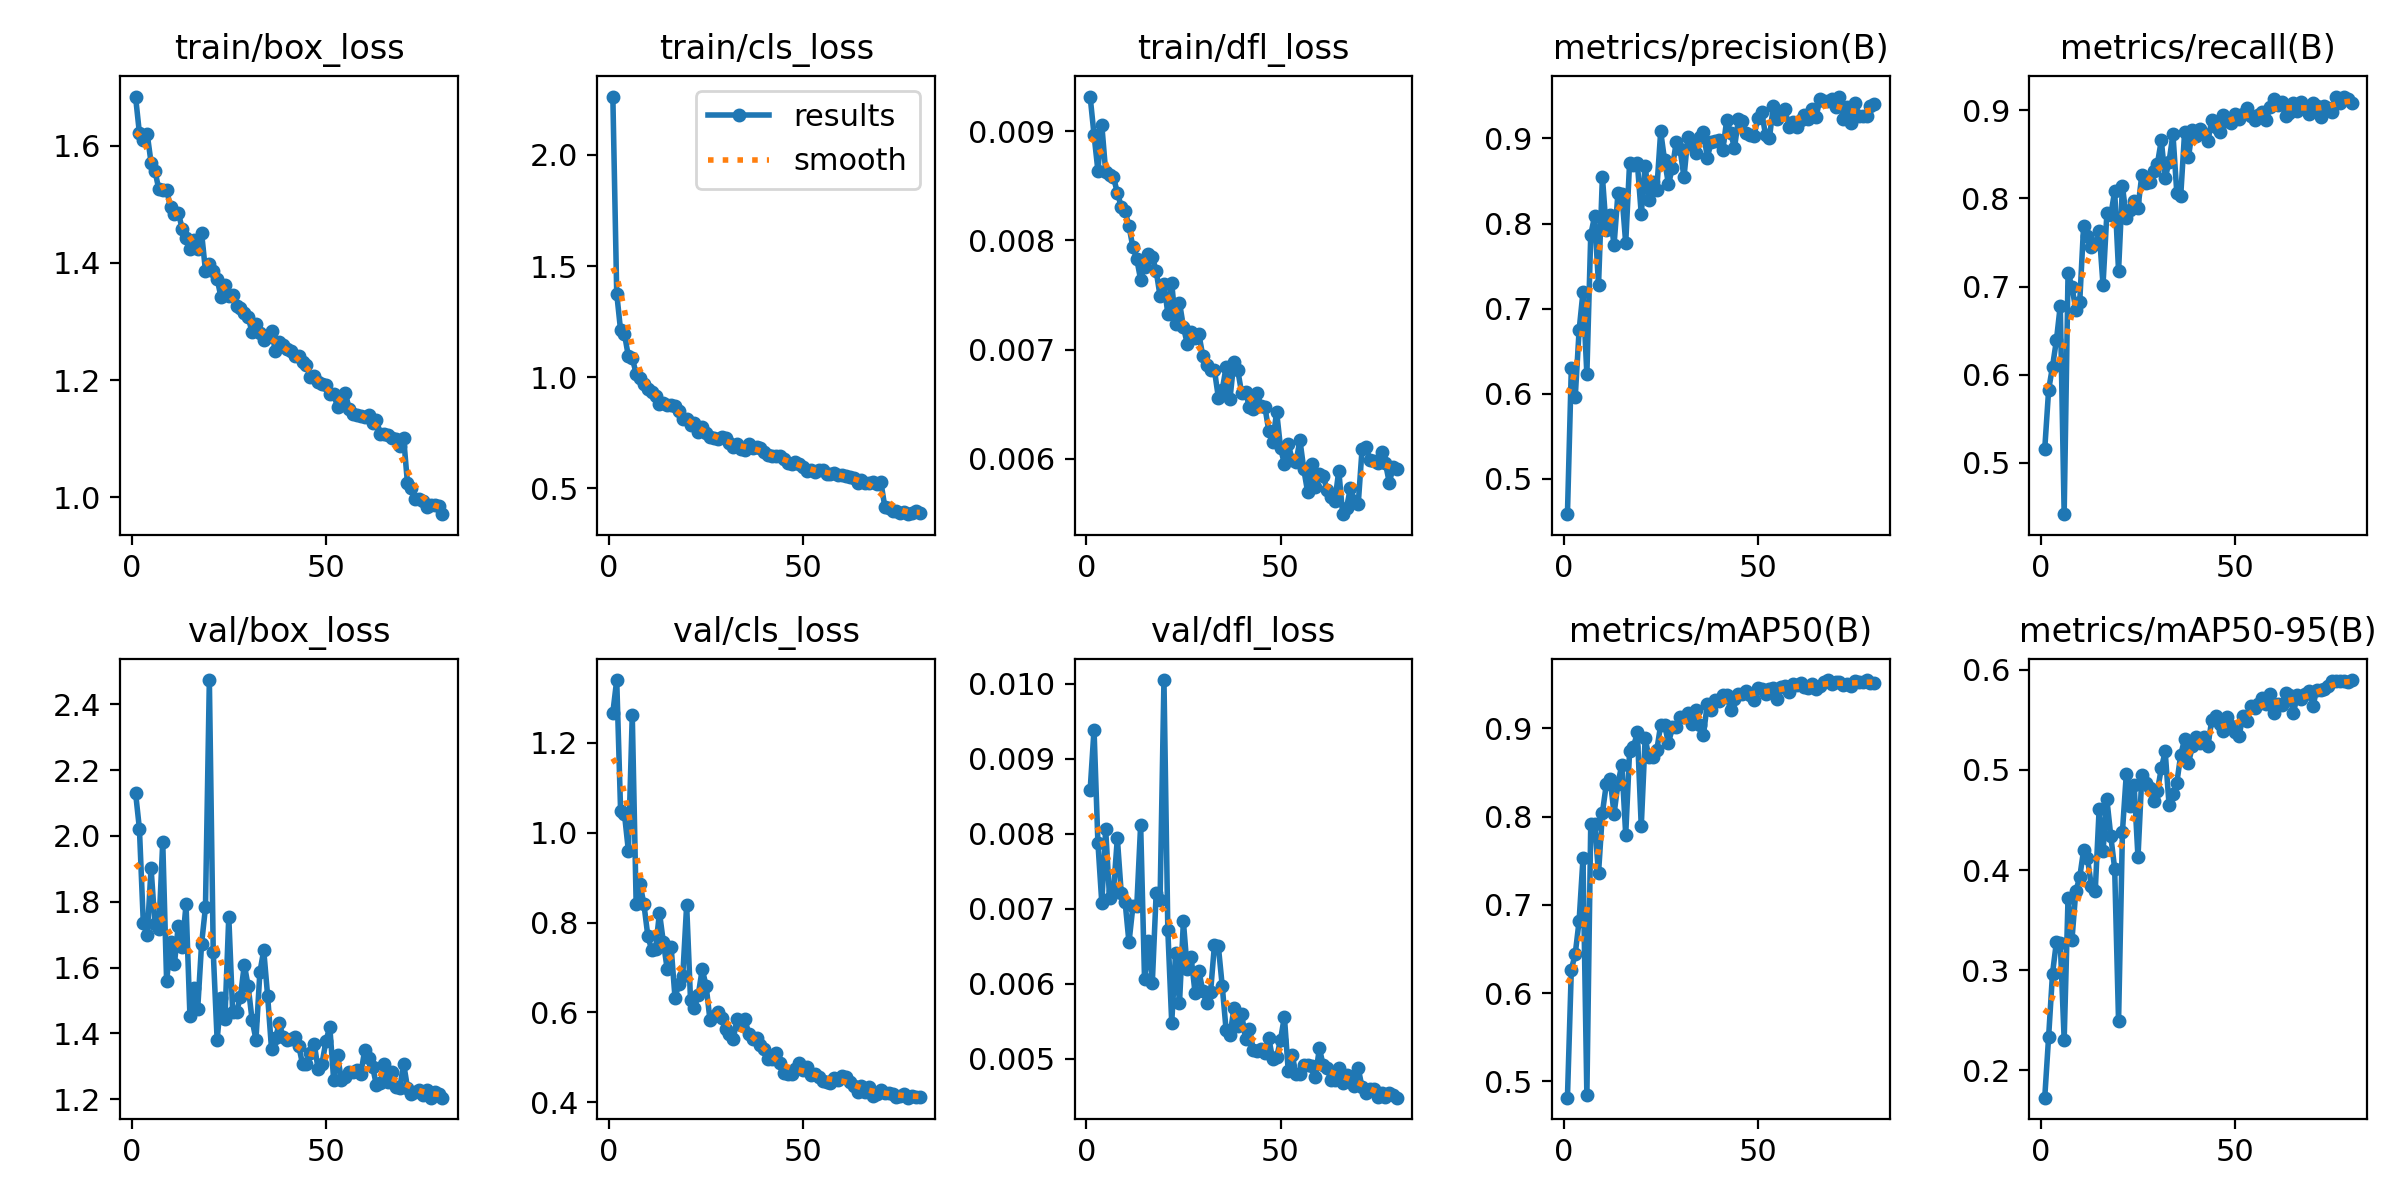

No encontrado: /content/runs/detect/train/PR_curve.png
No encontrado: /content/runs/detect/train/P_curve.png
No encontrado: /content/runs/detect/train/R_curve.png
No encontrado: /content/runs/detect/train/F1_curve.png

Mostrando: confusion_matrix.png


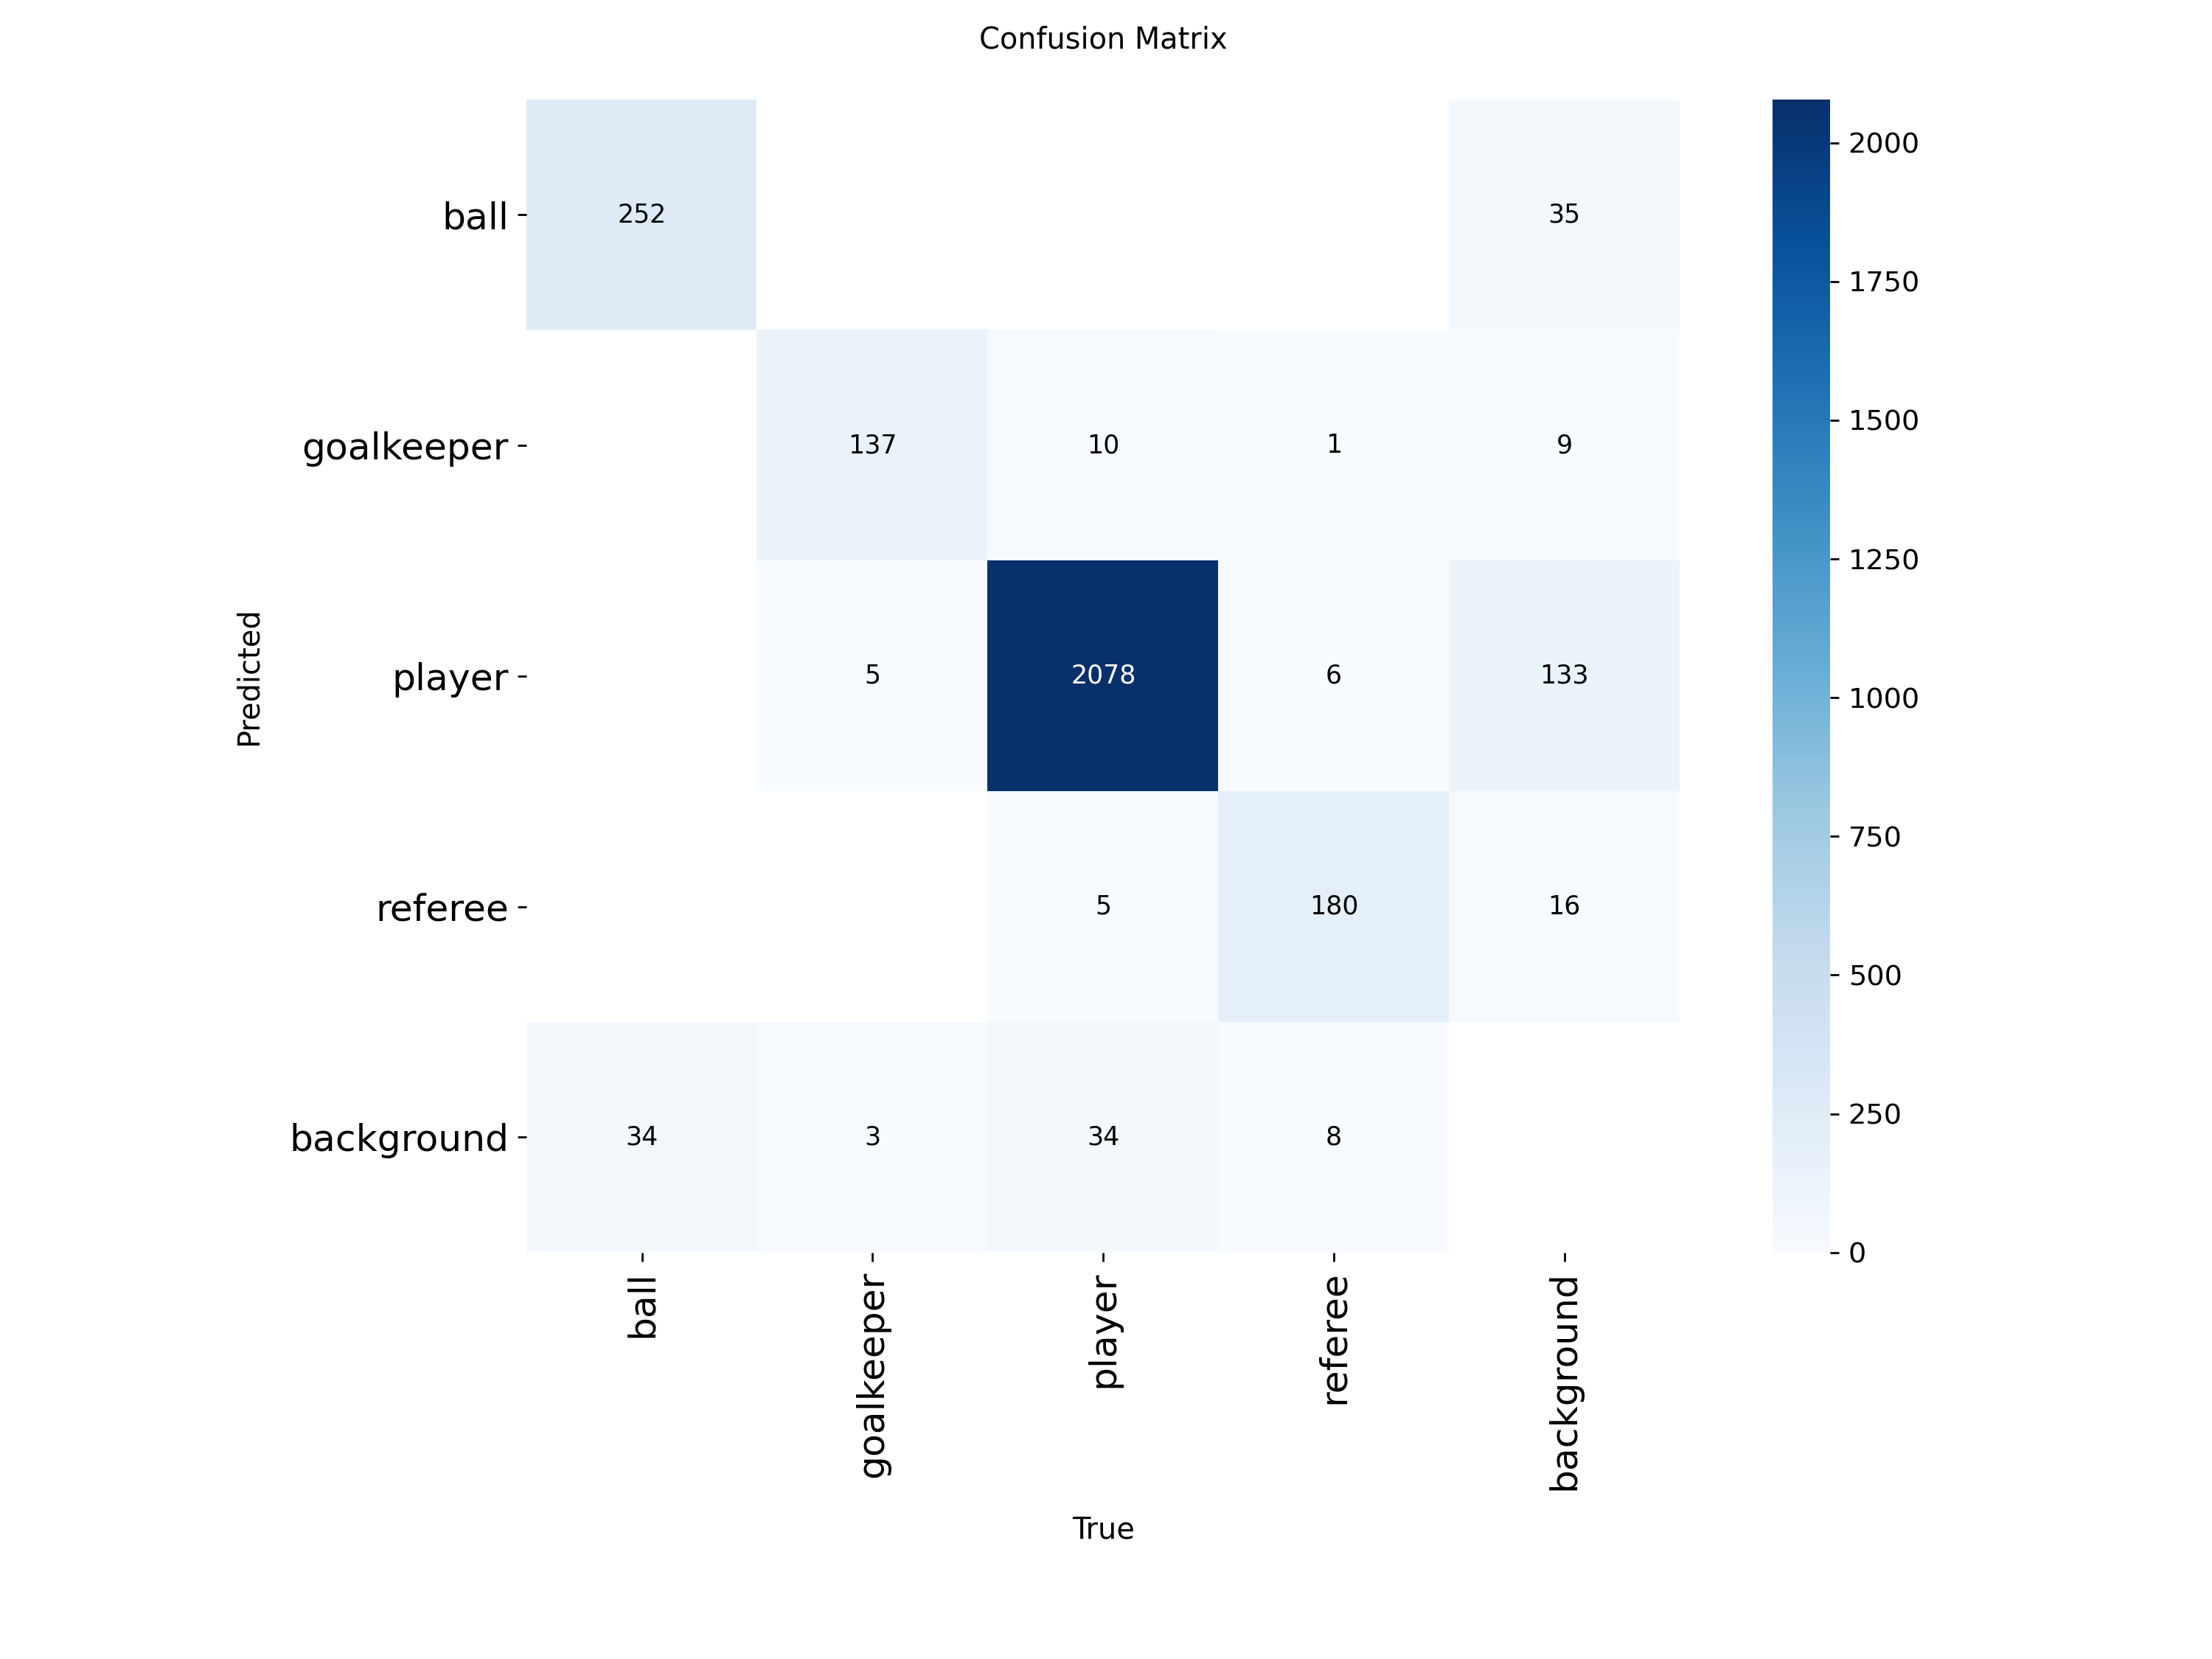


Mostrando: confusion_matrix_normalized.png


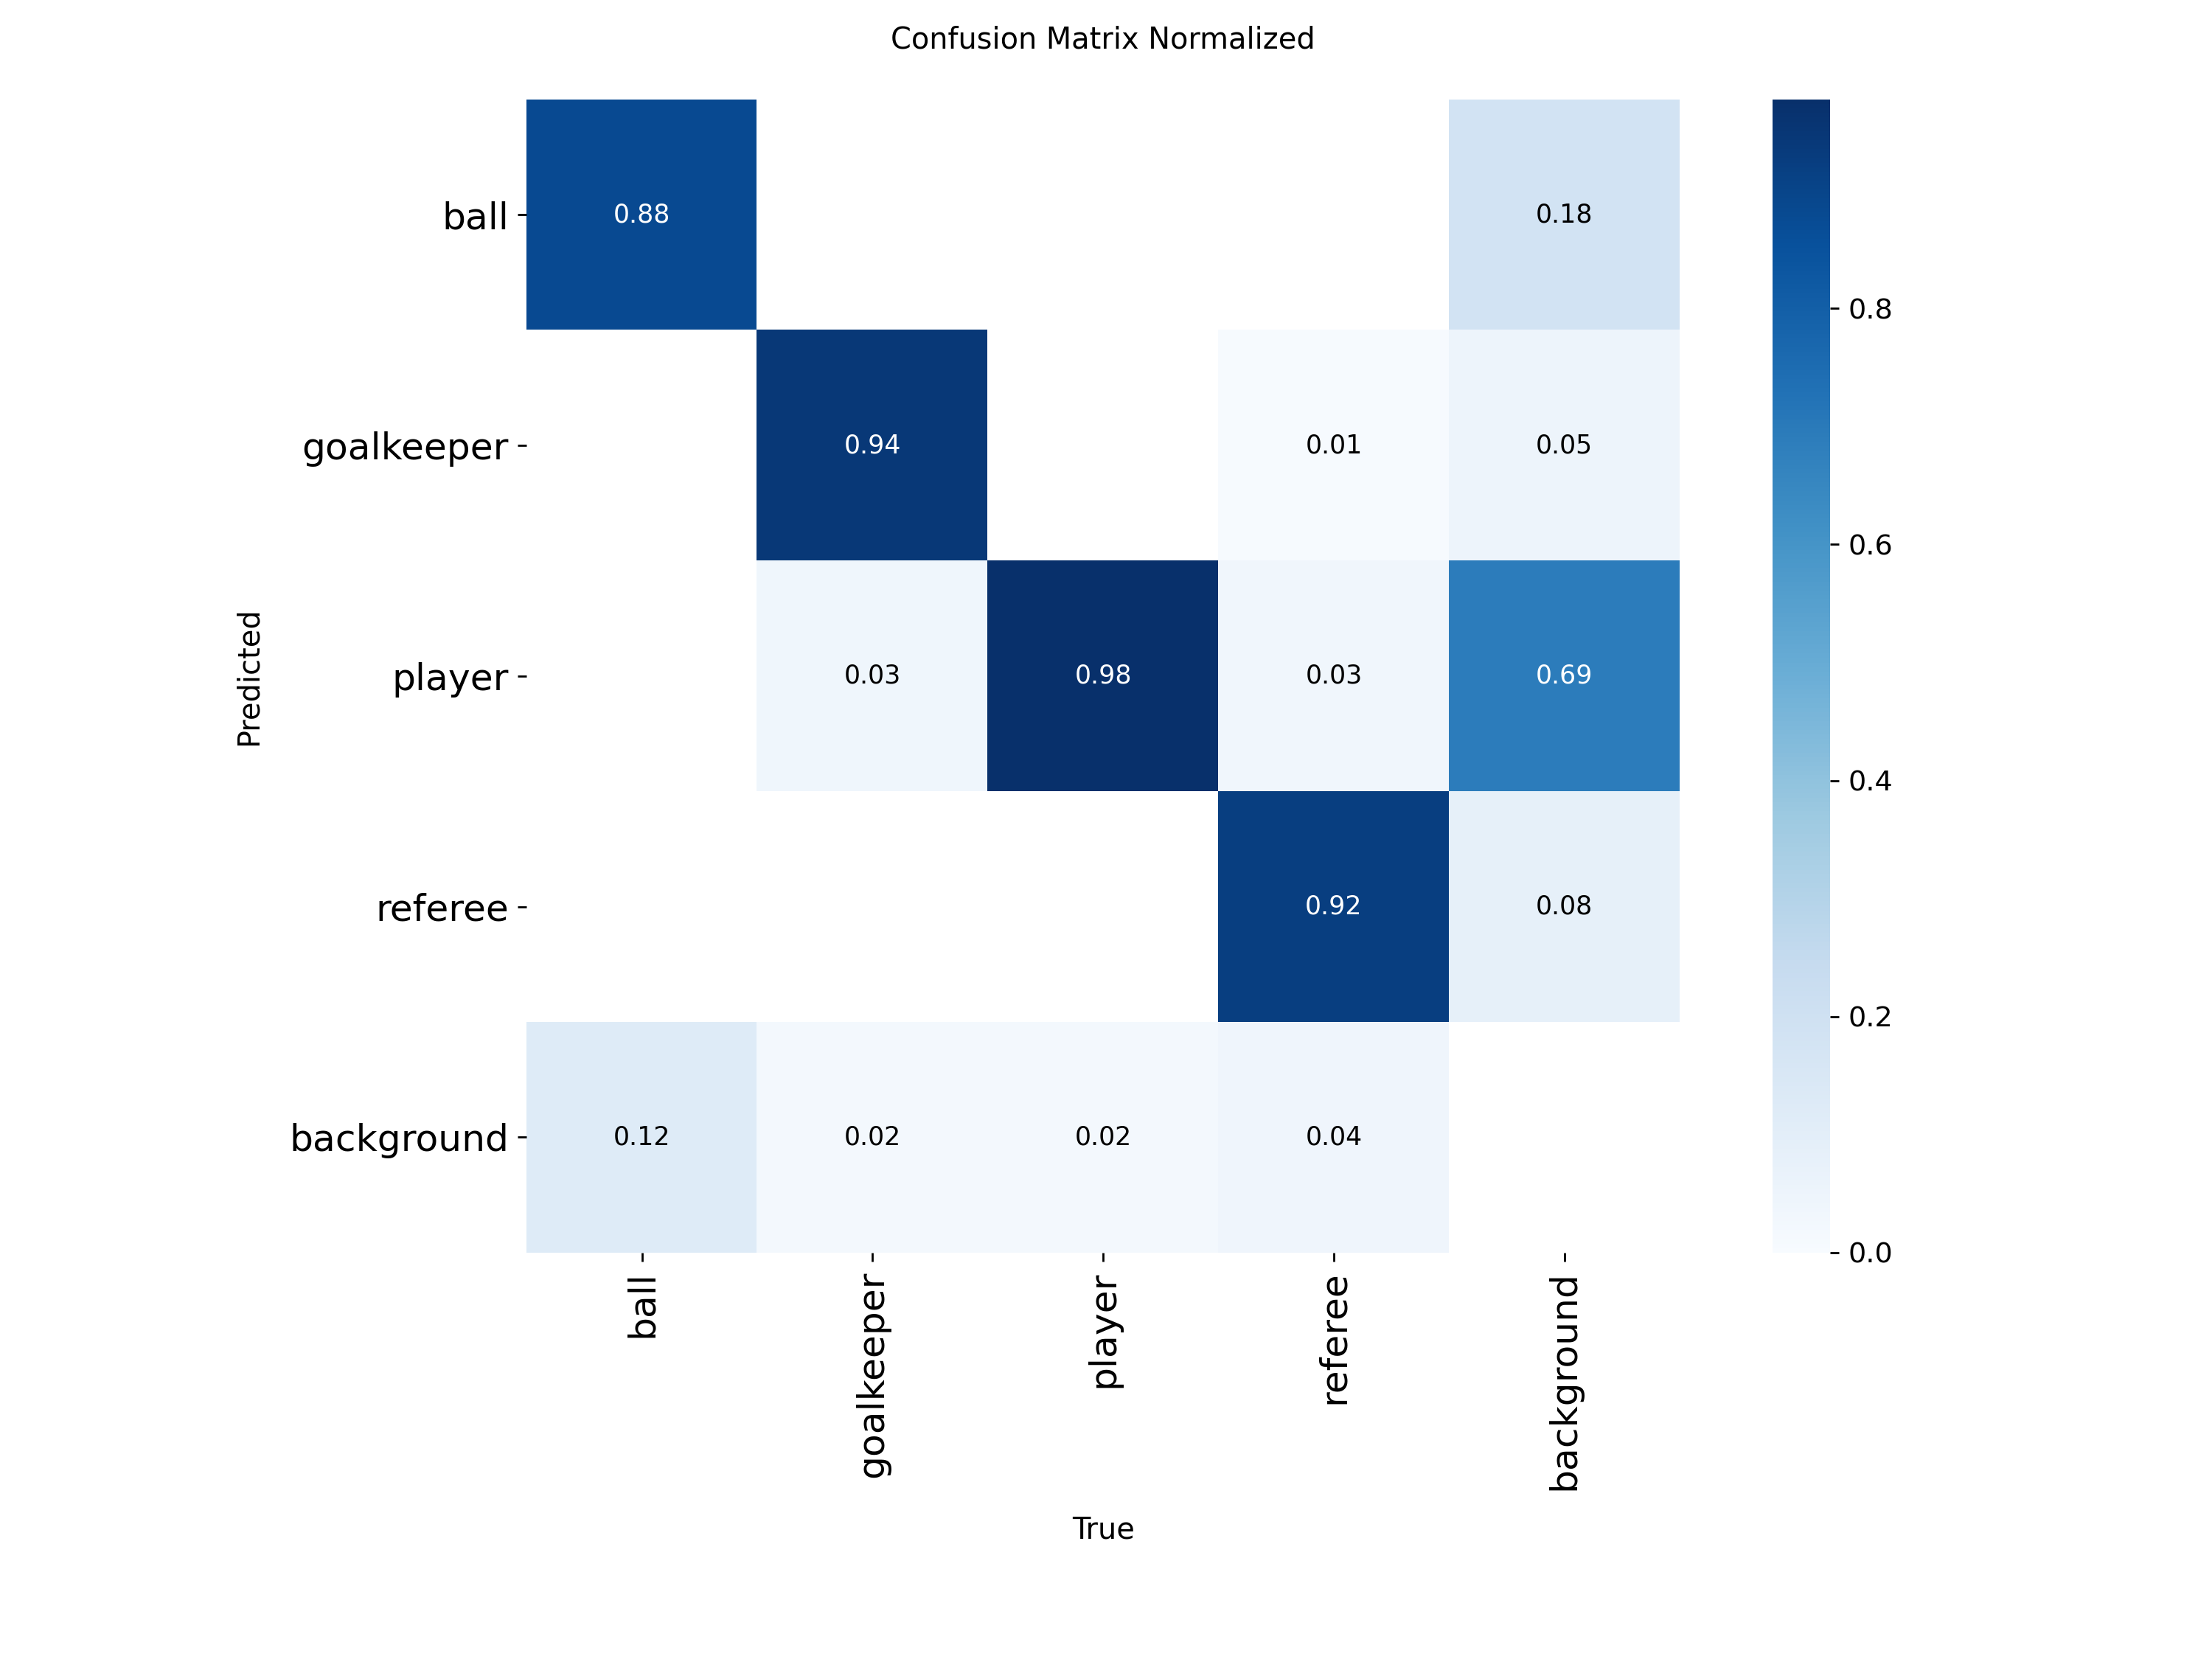

In [10]:
run_dir = "/content/runs/detect/train"

files_to_show = [
    "results.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
]

for fname in files_to_show:
    fpath = os.path.join(run_dir, fname)
    if os.path.exists(fpath):
        print(f"\nMostrando: {fname}")
        display(Image(filename=fpath))
    else:
        print(f"No encontrado: {fpath}")

### Guardo el modelo

In [11]:
origen = "/content/runs/detect/train/weights/best.pt"  # cambiar a segment si corresponde
destino = "/content/drive/MyDrive/modelos_SoccerNet_yolo26/best.pt"

os.makedirs(os.path.dirname(destino), exist_ok=True)
shutil.copy(origen, destino)

print("Modelo guardado en:", destino)

Modelo guardado en: /content/drive/MyDrive/modelos_SoccerNet_yolo26/best.pt


### Prueba en un video

In [12]:
!pip install ultralytics moviepy

model = YOLO("/content/drive/MyDrive/modelos_SoccerNet_yolo26/best.pt")

model.predict(source="gol.mp4", save=True, project="resultados", name="prueba_video", exist_ok=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/180) /content/gol.mp4: 320x640 1 ball, 1 goalkeeper, 16 players, 88.2ms
video 1/1 (frame 2/180) /content/gol.mp4: 320x640 1 goalkeeper, 17 players, 12.7ms
video 1/1 (frame 3/180) /content/gol.mp4: 320x640 1 goalkeeper, 16 players, 16.0ms
video 1/1 (frame 4/180) /content/gol.mp4: 320x640 1 goalkeeper, 16 players, 15.7ms
video 1/1 (frame 5/180) /content/gol.mp4: 320x640 1 goalkeeper, 17 players, 15.5ms
video 1/1 (frame 6/180) /content/go

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'ball', 1: 'goalkeeper', 2: 'player', 3: 'referee'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
 